<a href="https://colab.research.google.com/github/akhilrattan/machine-learning/blob/main/svmclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

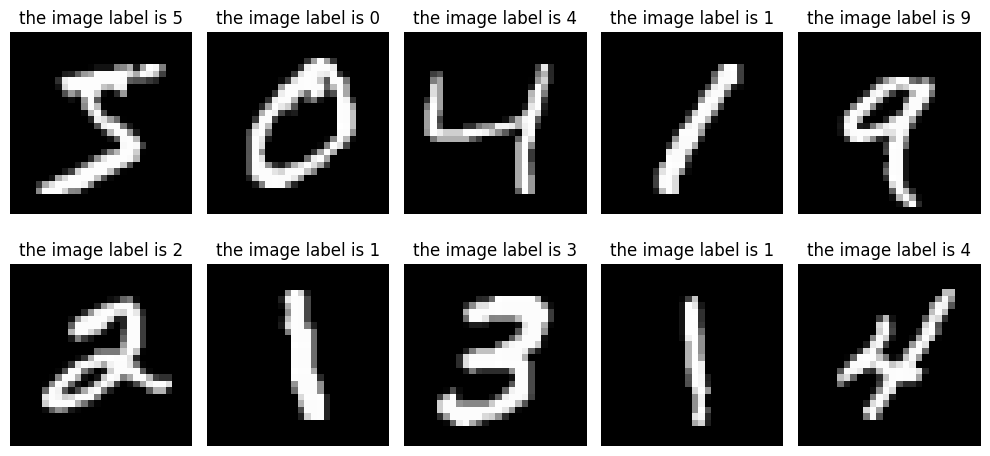


Training Samples : 48000
testing samples 12000
Linear SVM Accuracy : 0.9350
RBF SVM Accuracy : 0.9772


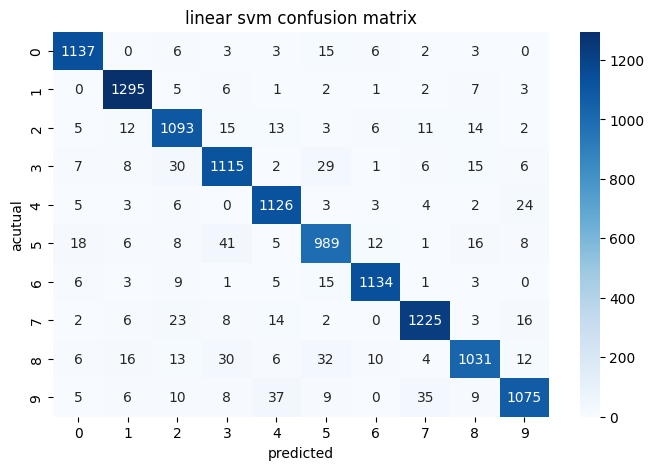

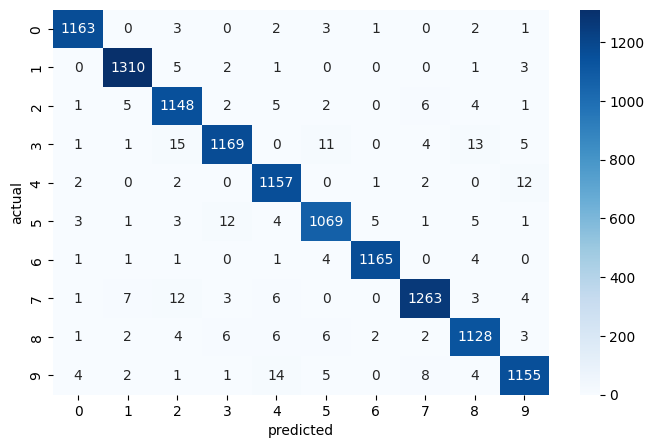


Linear SVM Metrics
Accuracy : 0.935
Precision: 0.9350321729306706
Recall   : 0.935
F1 Score : 0.9348641131927485

RBF SVM Metrics
Accuracy : 0.97725
Precision: 0.9772960013137446
Recall   : 0.97725
F1 Score : 0.9772440930700629


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report

)


df = pd.read_csv('/mnist_train.csv')

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    image = df.iloc[i,1:].values.reshape(28,28)
    plt.imshow(image,cmap='gray')
    plt.title(f"the image label is {df.iloc[i,0]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

X = df.drop("label",axis=1)
y = df["label"]

X_train ,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("\nTraining Samples :", X_train.shape[0])
print("testing samples", X_test.shape[0])

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train,y_train)
linear_pred = linear_svm.predict(X_test)

rf_svm = SVC(kernel='rbf')
rf_svm.fit(X_train,y_train)
rf_pred = rf_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test,linear_pred)
rbf_accuracy = accuracy_score(y_test,rf_pred)


print(f"Linear SVM Accuracy : {linear_accuracy:.4f}")
print(f"RBF SVM Accuracy : {rbf_accuracy:.4f}")

linear_cm = confusion_matrix(y_test,linear_pred)
rbf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,5))
sns.heatmap(
    linear_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('linear svm confusion matrix')
plt.xlabel('predicted')
plt.ylabel('acutual')
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(
    rbf_cm,
    annot=True,
    fmt = 'd',
    cmap='Blues'
)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

print("\nLinear SVM Metrics")

print("Accuracy :", accuracy_score(y_test, linear_pred))
print("Precision:", precision_score(y_test, linear_pred, average='weighted'))
print("Recall   :", recall_score(y_test, linear_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, linear_pred, average='weighted'))

print("\nRBF SVM Metrics")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average='weighted'))
print("Recall   :", recall_score(y_test, rf_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, rf_pred, average='weighted'))






